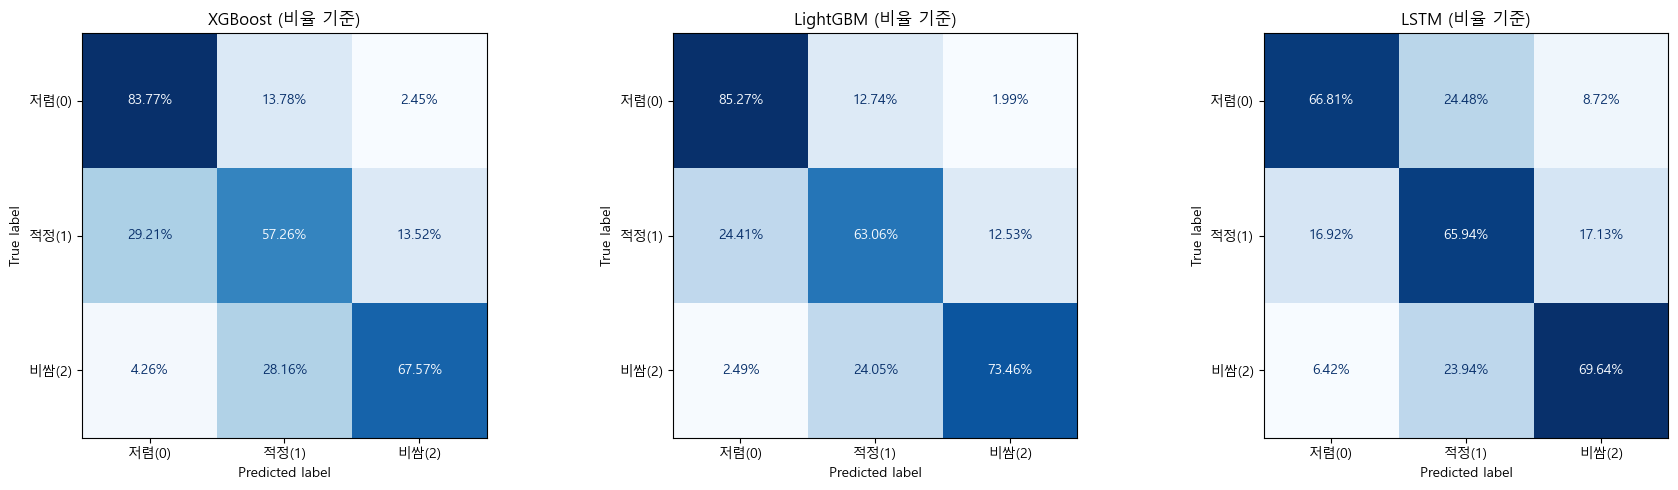

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# =========================
# 한글 폰트 설정 (Windows 기준)
# =========================
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# =========================
# 클래스 라벨
# =========================
labels = ["저렴(0)", "적정(1)", "비쌈(2)"]

# =========================
# Confusion Matrix 데이터
# =========================
cm_xgb = np.array([
    [11934, 1963,  349],
    [ 4725, 9262, 2187],
    [  930, 6144, 14742]
])


cm_lgbm = np.array([
    [12148, 1815,  283],
    [ 3948, 10200, 2026],
    [  544, 5247, 16025]
])

cm_lstm = np.array([
    [11826,  4333,  1543],
    [ 2635, 10268,  2668],
    [  936,  3488, 10147]
])

# =========================
# 행 기준 정규화 (비율)
# =========================
def normalize_cm(cm):
    return cm / cm.sum(axis=1, keepdims=True)

cms = [
    normalize_cm(cm_xgb),
    normalize_cm(cm_lgbm),
    normalize_cm(cm_lstm)
]

titles = ["XGBoost", "LightGBM", "LSTM"]

# =========================
# 시각화
# =========================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, cm, title in zip(axes, cms, titles):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels
    )
    disp.plot(
        ax=ax,
        cmap="Blues",
        values_format=".2%",   # ✅ 비율(%) 표시
        colorbar=False
    )
    ax.set_title(f"{title} (비율 기준)")

plt.tight_layout()
plt.show()


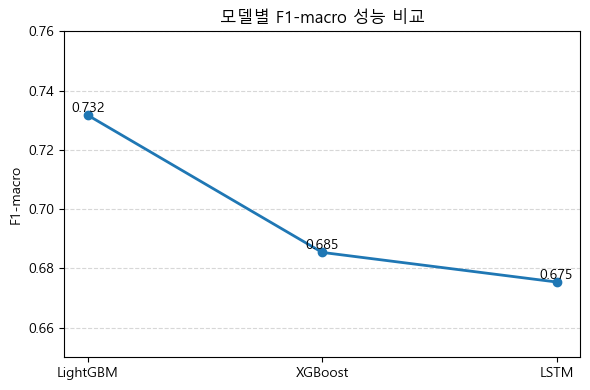

In [2]:
import matplotlib.pyplot as plt

# 한글 폰트 설정 (Windows)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 데이터
models = ["LightGBM", "XGBoost", "LSTM"]
f1_macro = [0.7317, 0.6854, 0.6754]

# 선 그래프
plt.figure(figsize=(6, 4))
plt.plot(models, f1_macro, marker="o", linewidth=2)

# 값 표시
for x, y in zip(models, f1_macro):
    plt.text(x, y, f"{y:.3f}", ha="center", va="bottom")

plt.ylim(0.65, 0.76)
plt.ylabel("F1-macro")
plt.title("모델별 F1-macro 성능 비교")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


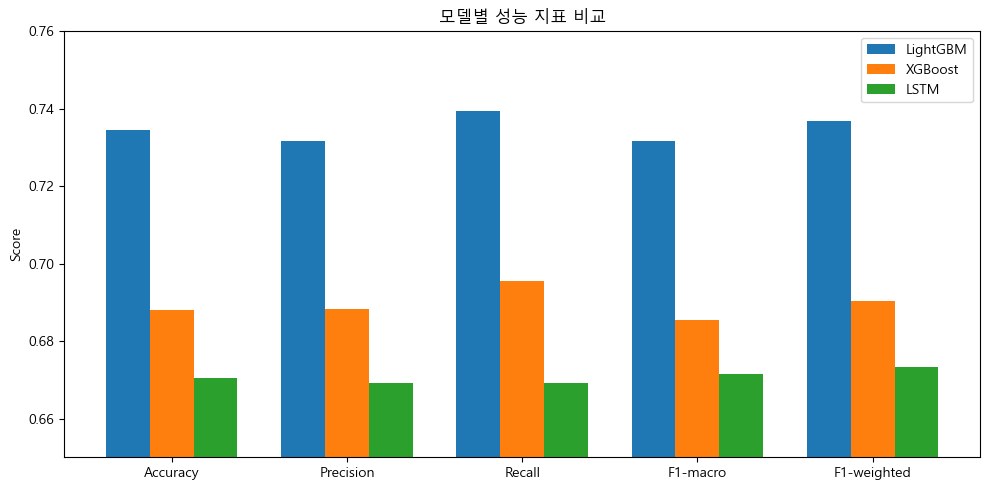

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 데이터
models = ["LightGBM", "XGBoost", "LSTM"]
metrics = ["Accuracy", "Precision", "Recall", "F1-macro", "F1-weighted"]

values = [
    [0.7346, 0.7317, 0.7393, 0.7317, 0.7368],  # LightGBM
    [0.6880, 0.6883, 0.6954, 0.6854, 0.6904],  # XGBoost
    [0.6704, 0.6693, 0.6693, 0.6715, 0.6734],  # LSTM
]

values = np.array(values)

# 시각화
x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(10, 5))
for i, model in enumerate(models):
    plt.bar(x + i * width, values[i], width, label=model)

plt.xticks(x + width, metrics)
plt.ylim(0.65, 0.76)
plt.ylabel("Score")
plt.title("모델별 성능 지표 비교")
plt.legend()
plt.tight_layout()
plt.show()
